# Chapter 4 — Representing Data and Engineering Features

Chapter ini membahas pentingnya representasi data dan rekayasa fitur.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. One-Hot Encoding

Fitur kategorikal harus diubah menjadi numerik agar dapat diproses oleh model.

In [2]:
data = pd.DataFrame({'kota':['Bandung','Jakarta','Bandung','Surabaya'], 'tipe':['baru','lama','lama','baru'], 'transaksi':[3,10,7,2]})
encoded = pd.get_dummies(data, columns=['kota','tipe'])
print(encoded)

   transaksi  kota_Bandung  kota_Jakarta  kota_Surabaya  tipe_baru  tipe_lama
0          3          True         False          False       True      False
1         10         False          True          False      False       True
2          7          True         False          False      False       True
3          2         False         False           True       True      False


## 2. Binning dan Model Linear

Binning membagi fitur kontinu menjadi interval sehingga model linear bisa menangkap pola nonlinear sederhana.

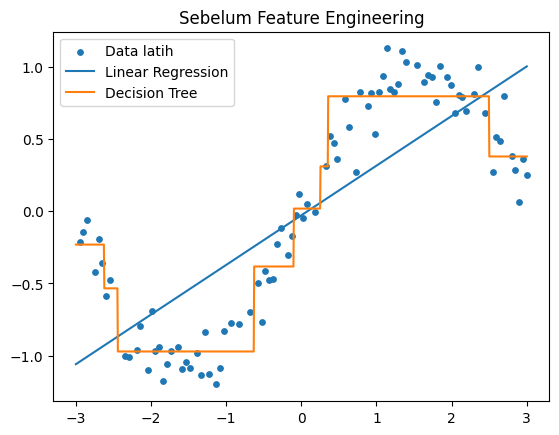

In [3]:
from sklearn.preprocessing import KBinsDiscretizer, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline
rng = np.random.RandomState(RANDOM_STATE)
X = np.linspace(-3,3,120).reshape(-1,1)
y = np.sin(X).ravel() + rng.normal(scale=0.15, size=120)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=RANDOM_STATE)
line = np.linspace(-3,3,1000).reshape(-1,1)
lin = LinearRegression().fit(X_train,y_train)
tree = DecisionTreeRegressor(max_depth=3, random_state=RANDOM_STATE).fit(X_train,y_train)
plt.scatter(X_train,y_train,s=15,label='Data latih')
plt.plot(line, lin.predict(line), label='Linear Regression')
plt.plot(line, tree.predict(line), label='Decision Tree')
plt.legend(); plt.title('Sebelum Feature Engineering'); plt.show()

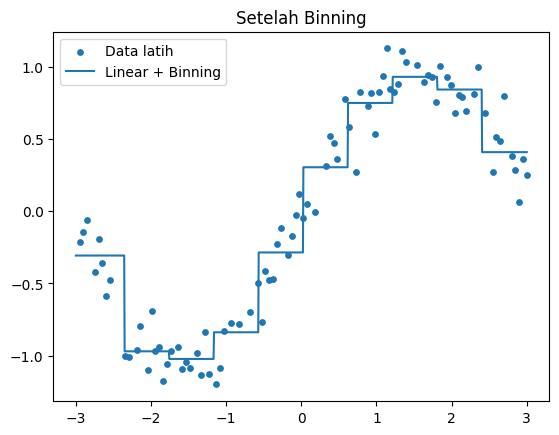

In [4]:
binner = KBinsDiscretizer(n_bins=10, encode='onehot-dense', strategy='uniform')
X_train_bin = binner.fit_transform(X_train)
line_bin = binner.transform(line)
lin_bin = LinearRegression().fit(X_train_bin, y_train)
plt.scatter(X_train,y_train,s=15,label='Data latih')
plt.plot(line, lin_bin.predict(line_bin), label='Linear + Binning')
plt.legend(); plt.title('Setelah Binning'); plt.show()

## 3. Polynomial Features

Polynomial features menambahkan fitur pangkat dan interaksi sehingga model linear menjadi lebih fleksibel.

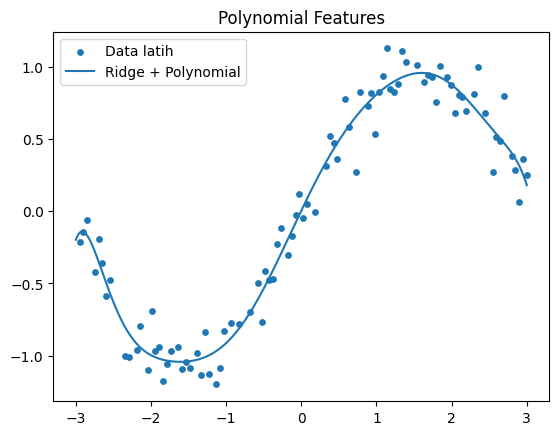

R2 train: 0.968
R2 test : 0.968


In [5]:
poly_model = Pipeline([('poly', PolynomialFeatures(degree=10, include_bias=False)), ('ridge', Ridge(alpha=0.01))])
poly_model.fit(X_train, y_train)
plt.scatter(X_train,y_train,s=15,label='Data latih')
plt.plot(line, poly_model.predict(line), label='Ridge + Polynomial')
plt.legend(); plt.title('Polynomial Features'); plt.show()
print('R2 train:', round(poly_model.score(X_train,y_train),3))
print('R2 test :', round(poly_model.score(X_test,y_test),3))

## 4. Feature Selection

Feature selection memilih fitur yang paling relevan dan mengurangi noise.

In [6]:
from sklearn.datasets import make_classification
from sklearn.feature_selection import SelectPercentile, f_classif
X_cls, y_cls = make_classification(n_samples=300, n_features=30, n_informative=5, n_redundant=5, random_state=RANDOM_STATE)
selector = SelectPercentile(f_classif, percentile=30)
X_sel = selector.fit_transform(X_cls, y_cls)
print('Shape awal:', X_cls.shape)
print('Shape setelah seleksi:', X_sel.shape)
print('Indeks fitur terpilih:', np.where(selector.get_support())[0])

Shape awal: (300, 30)
Shape setelah seleksi: (300, 9)
Indeks fitur terpilih: [ 3  5  8 13 15 18 21 23 29]


## Kesimpulan

Representasi fitur sering menentukan keberhasilan model. One-hot encoding, binning, polynomial features, dan feature selection adalah teknik penting untuk meningkatkan kualitas input.